In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
x= 6*np.random.rand(200,1)-3
y= 0.8*x**2+0.9*x+2+np.random.rand(200,1)

In [4]:
x

array([[ 1.07983601],
       [-0.8782208 ],
       [ 1.08057552],
       [-0.66398703],
       [ 0.22388455],
       [-0.11609191],
       [ 0.30394781],
       [-0.41328204],
       [-2.2134654 ],
       [ 1.3088638 ],
       [ 2.1280717 ],
       [-1.16876929],
       [ 1.93773992],
       [ 2.7831667 ],
       [ 2.65985097],
       [-2.61309076],
       [ 2.84517581],
       [ 2.50114539],
       [-2.21736291],
       [ 1.35929283],
       [-0.16945117],
       [ 0.14982481],
       [-0.73078621],
       [-2.24896408],
       [ 1.78864831],
       [-1.85721562],
       [ 2.05879503],
       [-2.94040704],
       [-0.76119418],
       [ 1.47431578],
       [ 2.9119713 ],
       [ 0.96378367],
       [ 0.5618183 ],
       [-1.92231874],
       [ 1.0554046 ],
       [-1.84392   ],
       [-1.1878677 ],
       [-1.17853133],
       [-0.51950155],
       [-0.65067888],
       [-2.24432725],
       [-2.624294  ],
       [ 2.37508521],
       [-2.82495106],
       [-1.81220973],
       [ 0

In [5]:
y

array([[ 5.17500211],
       [ 3.36811473],
       [ 5.83083854],
       [ 3.44160662],
       [ 3.80718362],
       [ 3.15578298],
       [ 3.58634699],
       [ 2.77665707],
       [ 6.49902705],
       [ 6.67052052],
       [ 9.55903776],
       [ 3.12715212],
       [ 8.58574412],
       [13.92683521],
       [12.60768344],
       [ 7.92855228],
       [14.18846748],
       [11.96632103],
       [ 5.73757149],
       [ 5.90418686],
       [ 3.04355425],
       [ 3.41956379],
       [ 3.13418615],
       [ 6.7788634 ],
       [ 8.14456026],
       [ 5.41544449],
       [ 9.70527993],
       [ 9.0000565 ],
       [ 3.49164205],
       [ 6.64144388],
       [14.47670294],
       [ 4.63637553],
       [ 3.82008195],
       [ 5.07336932],
       [ 5.0480749 ],
       [ 4.78281138],
       [ 3.81423913],
       [ 3.20156723],
       [ 3.05859036],
       [ 3.13736407],
       [ 5.88965758],
       [ 8.06230791],
       [11.4502152 ],
       [ 8.35801671],
       [ 5.26135217],
       [ 3

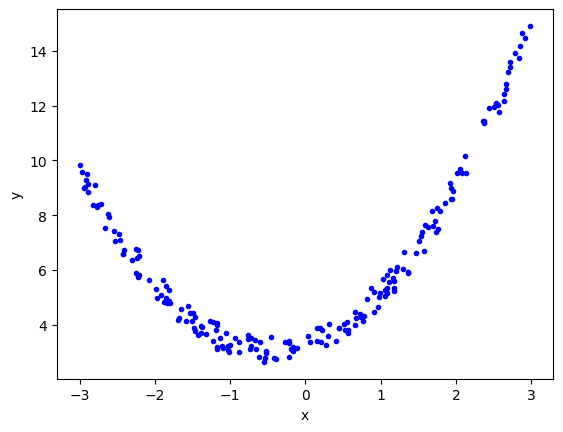

In [6]:
plt.plot(x,y,'b.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
#train and test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=3)

In [8]:
#applying the LR model

lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = lr.predict(x_test)
r2_score_lr = r2_score(y_test, y_pred)
print("R2 Score is:", r2_score_lr)

R2 Score is: 0.03212404243651856


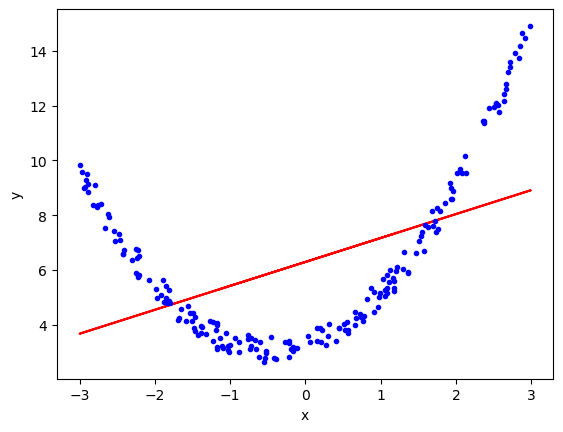

In [12]:
plt.plot(x_train, lr.predict(x_train),color='r')
plt.plot(x, y,'b.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [14]:
#Applying polynomial linear regression

poly = PolynomialFeatures(degree=2, include_bias=True)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [15]:
print(x_train[0])

[1.16017255]


In [16]:
print(x_train_trans[0])

[1.         1.16017255 1.34600035]


In [17]:
lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = lr2.predict(x_test_trans)

In [21]:
r2_score(y_test, y_pred)

0.990317497625679

In [22]:
print(lr2.coef_)

[[0.         0.92069049 1.01309756]]


In [23]:
print(lr2.intercept_)

[3.26134527]


In [27]:
x_new = np.linspace(-3, 3, 200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr2.predict(x_new_poly)

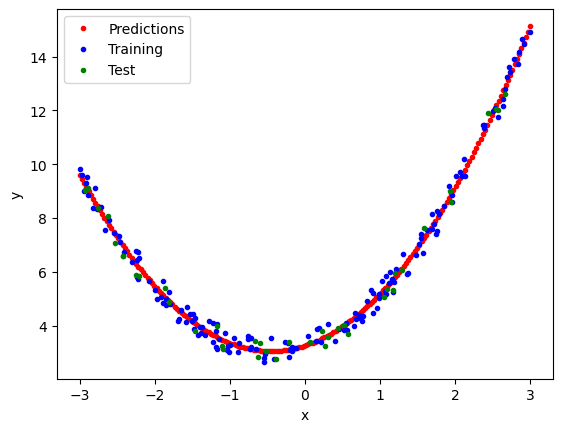

In [29]:
plt.plot(x_new, y_new, "r.", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.", label="Training")
plt.plot(x_test, y_test, "g.", label="Test")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()